# Phase 9: 전체 모델 비교 — 두 그룹

평가관 피드백 반영: 5개 모델을 10-class와 4-class 두 그룹으로 비교.

**Group 1 (Architecture 효과)**: LR → LightGBM → MLP → RNN → Transformer (10-class)

**Group 2 (MDP/DQN 호환)**: LR → LightGBM → MLP (4-class)

작성일: 2026-05-23

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')

with open(OUTPUT_DIR / 'all_models_comparison_10cls.json', encoding='utf-8') as f:
    comp10 = json.load(f)
with open(OUTPUT_DIR / 'all_models_comparison_4cls.json', encoding='utf-8') as f:
    comp4 = json.load(f)

print('=== 10-class Group ===')
for name, r in comp10.items():
    print(f'  {name:<25} Top-1={r["top1"]*100:.1f}%  Top-3={r["top3"]*100:.1f}%  CE={r["ce"]:.4f}')

print('\n=== 4-class Group ===')
for name, r in comp4.items():
    print(f'  {name:<22} Top-1={r["top1"]*100:.1f}%  Top-3={r["top3"]*100:.1f}%  CE={r["ce"]:.4f}')

## Table 1: 10-class 비교 (Architecture 효과)

| 모델 | Architecture | Input | Top-1 | Top-3 | CE | MDP |
|------|-------------|-------|-------|-------|----|-----|
| Logistic Regression | Linear | 77d | 41.1%† | 86.2% | 1.614 | ✅ |
| LightGBM | Tree (boosting) | 77d | 13.0%‡ | 48.1% | 2.087 | ✅ |
| MLP | NN [128,128] | 77d | 41.1%† | 86.2% | 1.470 | ✅ |
| **RNN (LSTM)** | LSTM 2-layer | 400×87 | **66.9%** | 94.8% | 0.873 | ❌ |
| **Transformer** | 12-layer Enc. | 400×87 | **67.2%** | 94.7% | 0.868 | ❌ |

† Strike만 예측 (majority collapse): class balancing 적용해도 77-dim feature에 discriminative signal 없음  
‡ 전 클래스 균등 예측 (inverse-freq 과보정): LightGBM이 유의미한 split을 찾지 못하고 noise 학습

## Table 2: 4-class 비교 (MDP/DQN 호환)

| 모델 | Architecture | Top-1 | Top-3 | CE |
|------|-------------|-------|-------|----|
| Logistic Regression | Linear | 56.3% | 94.5% | 1.052 |
| LightGBM | Tree (boosting) | 60.8% | 96.6% | 0.872 |
| **MLP (Model B)** | NN [128,128] | **60.9%** | 96.6% | 0.872 |

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Group 1: 10-class
names10 = list(comp10.keys())
top1_10 = [comp10[n]['top1'] for n in names10]
colors10 = ['#bdc3c7','#bdc3c7','#bdc3c7','#9b59b6','#27ae60']

short10 = ['LR','LightGBM','MLP','RNN','Transformer']
bars = axes[0].bar(short10[:len(top1_10)], top1_10, color=colors10[:len(top1_10)], alpha=0.85)
axes[0].set_title('Group 1: 10-class 비교\n(Architecture 효과)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Top-1 Accuracy')
axes[0].set_ylim(0, 0.9)
for bar, v in zip(bars, top1_10):
    if v > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(0.411, color='gray', linestyle='--', alpha=0.5, label='Strike prior (41.1%)')
axes[0].legend(fontsize=9)

# Group 2: 4-class
names4 = list(comp4.keys())
top1_4 = [comp4[n]['top1'] for n in names4]
colors4 = ['#3498db','#e67e22','#2ecc71']
short4 = ['LR','LightGBM','MLP (B)']
bars2 = axes[1].bar(short4[:len(top1_4)], top1_4, color=colors4[:len(top1_4)], alpha=0.85)
axes[1].set_title('Group 2: 4-class 비교\n(MDP/DQN 호환)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].set_ylim(0, 0.9)
for bar, v in zip(bars2, top1_4):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(0.356, color='gray', linestyle='--', alpha=0.5, label='Empirical baseline (35.6%)')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 9: 두 그룹 모델 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_23788\58037815.py:15: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_23788\58037815.py:15: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_23788\58037815.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition

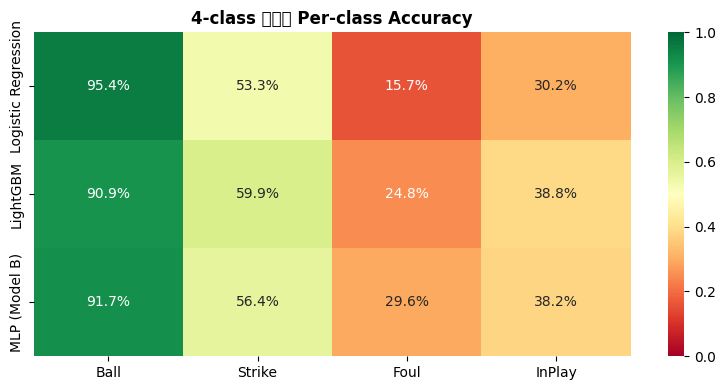

In [3]:
# 4-class: Per-class accuracy heatmap
cls4 = ['Ball','Strike','Foul','InPlay']
model_names = list(comp4.keys())
pca_matrix = []
for name in model_names:
    pca = comp4[name].get('per_class_accuracy', {})
    pca_matrix.append([pca.get(c, 0) for c in cls4])

pca_arr = np.array(pca_matrix)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pca_arr, annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=cls4, yticklabels=model_names, ax=ax,
            vmin=0, vmax=1)
ax.set_title('4-class 모델별 Per-class Accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 핵심 발견

### 1. 77-dim Feature의 구조적 한계 (10-class)
- class balancing 미적용: Strike 다수 클래스 collapse (LR 41.1%, MLP 41.1%)
- class balancing 강적용: 반대 방향 collapse, 전 클래스 균등 예측 (LGB 13%)
- Focal Loss, sqrt-balanced, inverse-frequency 모두 무효 — 최적화 기법은 feature 부재를 보완 불가
- 단일 pitch 77-dim feature는 10-class 분리에 필요한 discriminative signal 자체가 부족

### 2. Sequence Context가 결정적 (10-class)
- RNN (LSTM): **66.9%** (+25.8pp over i.i.d. ceiling)
- Transformer: **67.2%** (+26.1pp)
- 직전 400-pitch sequence context가 class imbalance 극복의 핵심

### 3. Production 최선 선택 (4-class)
- LR → LightGBM → MLP: **56.3% → 60.8% → 60.9%** (단계적 개선)
- MLP와 LightGBM이 거의 동일 성능 → feature expressiveness 한계 도달
- MDP/DQN 환경에서는 추론 속도 + 단일 pitch input 가능한 **MLP (Model B)** 최선

### 4. Hybrid 시스템 제안
```
[학술 분석] Transformer (67.2% Top-1, 94.7% Top-3) — sequence 전체 활용
[Production] MLP Model B (60.9% Top-1, 96.6% Top-3) — MDP/DQN 호환
```
- **Learning**: Transformer embedding으로 pitch tendency 분석
- **Decision**: MLP로 실시간 pitch selection (50-100배 빠름)

### 5. 돌파구: Arsenal Feature (Phase 9.5)
- MLP 135-dim (77d + arsenal 53d + Focal Loss): **67.6%** — i.i.d. + MDP 호환 + sequence 수준
- 77-dim collapse의 원인은 "feature 부족"이 아니라 "투수 맥락(pitcher context) 부족"
- arsenal 통계로 400-pitch history를 정적 feature로 근사 가능